In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pathlib
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn import metrics

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional, \
                        Conv1D, Flatten,MaxPooling1D, ConvLSTM2D, \
                        TimeDistributed, RepeatVector, Bidirectional
from keras.optimizers import Adam
import keras_tuner as kt

ROOT = pathlib.Path().resolve()
DATA_FOLDER = ROOT / "data/bike"

print(DATA_FOLDER)

C:\Users\PatCa\Documents\PythonScripts\test_projects\big_data\bike_data\data\bike


In [4]:
df = pd.read_parquet('all_years_weekly.parquet')
# Log data
df['log_trips'] = df['count_trips'].apply(lambda x: np.log(x))

# Make stationary
df['log_trips_shift'] = df['log_trips'].diff()

In [5]:
# Multi output step LSTM model
# Input is numpy arrays output is X[samples, in_step], y[samples]
def seq_multi_LSTM(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    X = np.array(X)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, np.array(y)


def print_curves(history, train_met, test_met):
    plt.figure()
    plt.plot(history.history[train_met], label='train')
    plt.plot(history.history[test_met], label='test')
    plt.title(train_met)
    plt.legend()
    plt.show()
    return


def lstm_model(Xtrain, n_output, n1=100, n2=50, d_out=0.0, lr=0.001):
    model = Sequential()
    model.add(LSTM(n1, activation='relu', return_sequences=True, input_shape=(Xtrain.shape[1], Xtrain.shape[2]), dropout=d_out))
    model.add(LSTM(n2, activation='relu', dropout=d_out))
    model.add(Dense(n_output))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics='mae')
    return model

def cnn_model(Xtrain, n_output, n1=100, n2=50, d_out=0.0, lr=0.001):
    model = Sequential()
    model.add(Conv1D(64,2,activation='relu', input_shape=(Xtrain.shape[1], Xtrain.shape[2])))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(n_output))
    model.compile(optimizer=Adam(learning_rate=lr),loss='mse', metrics='mae')
    return model


def cnn_model_hp(hp):
    model = Sequential()
    hp_filters = hp.Choice('filters', values=[16,32,48,64,80])
    hp_kernels = hp.Choice('kernel_size', values=[1,2,4])
    model.add(Conv1D(filters=hp_filters, kernel_size=hp_kernels, activation='relu', 
                     input_shape=(12,1)))
    model.add(MaxPooling1D())
    model.add(Flatten())
    hp_nodes = hp.Choice('units', values=[25, 50, 100, 200])
    model.add(Dense(units=hp_nodes, activation='relu'))
    model.add(Dense(1))
    
    hp_lr = hp.Choice('learning_rate', values=[0.01, 0.005,0.001])
    model.compile(optimizer=Adam(learning_rate=hp_lr),loss='mse', metrics='mae')
    return model


def pred_check(y_pred, y_true, y_train):
    pred_length = y_pred.shape[0]
    pred_date = df.iloc[-pred_length:,:].index
    train_length = y_train.shape[0]
    train_date = df.iloc[:train_length:,:].index
    
    ev = metrics.explained_variance_score(y_true, y_pred)
    mape_ = metrics.mean_absolute_percentage_error(y_true, y_pred)
    mae_ = metrics.mean_absolute_error(y_true, y_pred)
    rms = np.sqrt(metrics.mean_squared_error(y_true, y_pred))

    print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')

    plt.figure()
    plt.plot(train_date, y_train)
    plt.plot(pred_date, y_pred, color='orange')
    plt.plot(pred_date, y_true, color='purple', alpha=0.2)
    plt.show()
    return


In [6]:
# Make supervised learning problem based on input/output
n_input = 12
n_output = 1

test_length = int(df.shape[0] * 0.1)
train = df.iloc[:-test_length,:].dropna()
test = df.iloc[-test_length:,:].dropna()

Xtrain, ytrain = seq_multi_LSTM(train['log_trips_shift'], n_input, n_output)
Xtest, ytest = seq_multi_LSTM(test['log_trips_shift'], n_input, n_output)
print(Xtrain.shape)


(270, 12, 1)


In [7]:
#-------------------------- Basic multi step output LSTM -----------------------------------------------------
#model = cnn_model(Xtrain, n_output, n1=50, n2=50, d_out=0.2, lr=0.01)

# tuner = kt.RandomSearch(hypermodel=cnn_model_hp,
#                      objective='val_mae',
#                      max_trials=60,
#                      seed=27
#                      )

tuner = kt.Hyperband(hypermodel=cnn_model_hp,
                     objective='val_mae',
                     max_epochs=100,
                     factor=3,
                     hyperband_iterations=5,
                     project_name="hyper_1",
                     overwrite=True,
                     )


In [14]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
filters (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 48, 64, 80], 'ordered': True}
kernel_size (Choice)
{'default': 1, 'conditions': [], 'values': [1, 2, 4], 'ordered': True}
units (Choice)
{'default': 25, 'conditions': [], 'values': [25, 50, 100, 200], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.005, 0.001], 'ordered': True}


In [8]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner_data = tuner.search(Xtrain, ytrain, batch_size=64, epochs=100,
                    validation_data=(Xtest, ytest), verbose=0,
                    callbacks=[stop_early, tf.keras.callbacks.TensorBoard("tensorboard/logs")],
                    use_multiprocessing=True,
                    workers=4
                    )


INFO:tensorflow:Oracle triggered exit


In [9]:
tuner.results_summary()

Results summary
Results in .\hyper_1
Showing 10 best trials
Trial summary
Hyperparameters:
filters: 32
kernel_size: 4
units: 200
learning_rate: 0.005
tuner/epochs: 100
tuner/initial_epoch: 34
tuner/bracket: 4
tuner/round: 4
tuner/trial_id: 0144
Score: 0.13200873136520386
Trial summary
Hyperparameters:
filters: 48
kernel_size: 2
units: 200
learning_rate: 0.005
tuner/epochs: 100
tuner/initial_epoch: 34
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0205
Score: 0.13241197168827057
Trial summary
Hyperparameters:
filters: 48
kernel_size: 4
units: 200
learning_rate: 0.005
tuner/epochs: 34
tuner/initial_epoch: 12
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0215
Score: 0.1365046203136444
Trial summary
Hyperparameters:
filters: 48
kernel_size: 4
units: 25
learning_rate: 0.005
tuner/epochs: 34
tuner/initial_epoch: 12
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0226
Score: 0.13770313560962677
Trial summary
Hyperparameters:
filters: 32
kernel_size: 4
units: 200
learning_rate: 0.005
tuner/

Results summary
Results in .\hyper_1
Showing 10 best trials
Trial summary
Hyperparameters:
filters: 32
kernel_size: 4
units: 200
learning_rate: 0.005
tuner/epochs: 100
tuner/initial_epoch: 34
tuner/bracket: 4
tuner/round: 4
tuner/trial_id: 0144
Score: 0.13200873136520386
Trial summary
Hyperparameters:
filters: 48
kernel_size: 2
units: 200
learning_rate: 0.005
tuner/epochs: 100
tuner/initial_epoch: 34
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0205
Score: 0.13241197168827057
Trial summary
Hyperparameters:
filters: 48
kernel_size: 4
units: 200
learning_rate: 0.005
tuner/epochs: 34
tuner/initial_epoch: 12
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0215
Score: 0.1365046203136444
Trial summary
Hyperparameters:
filters: 48
kernel_size: 4
units: 25
learning_rate: 0.005
tuner/epochs: 34
tuner/initial_epoch: 12
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0226
Score: 0.13770313560962677
Trial summary
Hyperparameters:
filters: 32
kernel_size: 4
units: 200
learning_rate: 0.005
tuner/

Early train mae: 0.16, test mae: 0.16 
Last train mae: 0.16, test mae: 0.16 


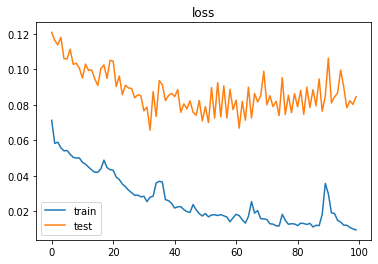

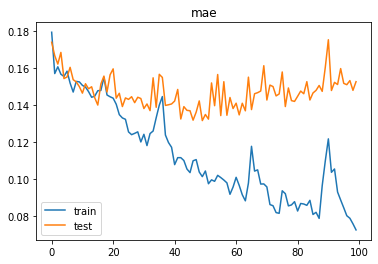

In [20]:
history = model.fit(Xtrain, ytrain, batch_size=64, epochs=100,
                    validation_data=(Xtest, ytest), verbose=0,)

train_first = history.history['mae'][5]
test_first = history.history['val_mae'][5]
train_last = history.history['mae'][-1]
test_last = history.history['val_mae'][-1]

print(f'Early train mae: {train_first:.2}, test mae: {test_first:.2} ')
print(f'Last train mae: {train_first:.2}, test mae: {test_first:.2} ')

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

Early train mae: 0.16, test mae: 0.16 
Last train mae: 0.16, test mae: 0.16 
